# Backend Parity and Performance

This notebook examines the numerical parity and performance of DustPy-GPU.

- The NumPy backend preserves the upstream DustPy result bitwise.
- NumPy and CuPy agree to strict FP64 tolerances at 1 kyr.
- Long-run backend differences remain small and oscillatory rather than accumulating with time.
- Standard DustPy examples retain the same physical evolution on the CuPy backend.
- Performance benchmarks quantify the GPU acceleration.

## 1. `DustPy-GPU` with `backend="numpy"` is in bitwise agreement with `DustPy`

The default 1 kyr model was evaluated with upstream DustPy 1.0.8 and DustPy-GPU 1.0.8.1 using `backend="numpy"`.

| Field | Bitwise agreement |
| :--- | :---: |
| `gas.Sigma` | **PASS** |
| `dust.Sigma` | **PASS** |

## 2. Parity between `DustPy-GPU` backends

### 2.1. Parity at 1 kyr

The default model is run sequentially with the NumPy and **CuPy backends**. The comparison uses `rtol=atol=1e-13`.

Minimal reproduction:

```python
import cupy as cp
import numpy as np
from simframe.frame import field_data

from dustpy import Simulation
from dustpy import constants as dc

def run_default_model(backend):
    sim = Simulation(backend=backend)
    sim.verbosity = 0
    sim.initialize()
    sim.t.snapshots = [0.0, 1_000.0 * dc.year]
    sim.writer = None
    sim.run()

    fields = {"gas.Sigma": sim.gas.Sigma, "dust.Sigma": sim.dust.Sigma}
    return {name: cp.asnumpy(field_data(value)) if backend == "cupy" else np.asarray(field_data(value)).copy() for name, value in fields.items()}

numpy_result = run_default_model("numpy")
cupy_result = run_default_model("cupy")

for name, reference in numpy_result.items():
    test = cupy_result[name]
    normalized_l2 = np.linalg.norm((test - reference).ravel()) / np.linalg.norm(reference.ravel())
    print(name, np.allclose(reference, test, rtol=1.0e-13, atol=1.0e-13), normalized_l2)
```

| Field | `np.allclose` | Normalized \(L_2\) |
| :--- | :---: | ---: |
| `gas.Sigma` | **PASS** | `1.25e-15` |
| `dust.Sigma` | **PASS** | `2.64e-14` |

### 2.2. Long-run trajectory comparison

The normalized \(L_2\) difference is

$$
\frac{\left\|\Sigma_{\rm CuPy}-\Sigma_{\rm NumPy}\right\|_2}
     {\left\|\Sigma_{\rm NumPy}\right\|_2}.
$$

The default model was followed to 200 kyr, with matched NumPy and CuPy snapshots every 5 kyr.

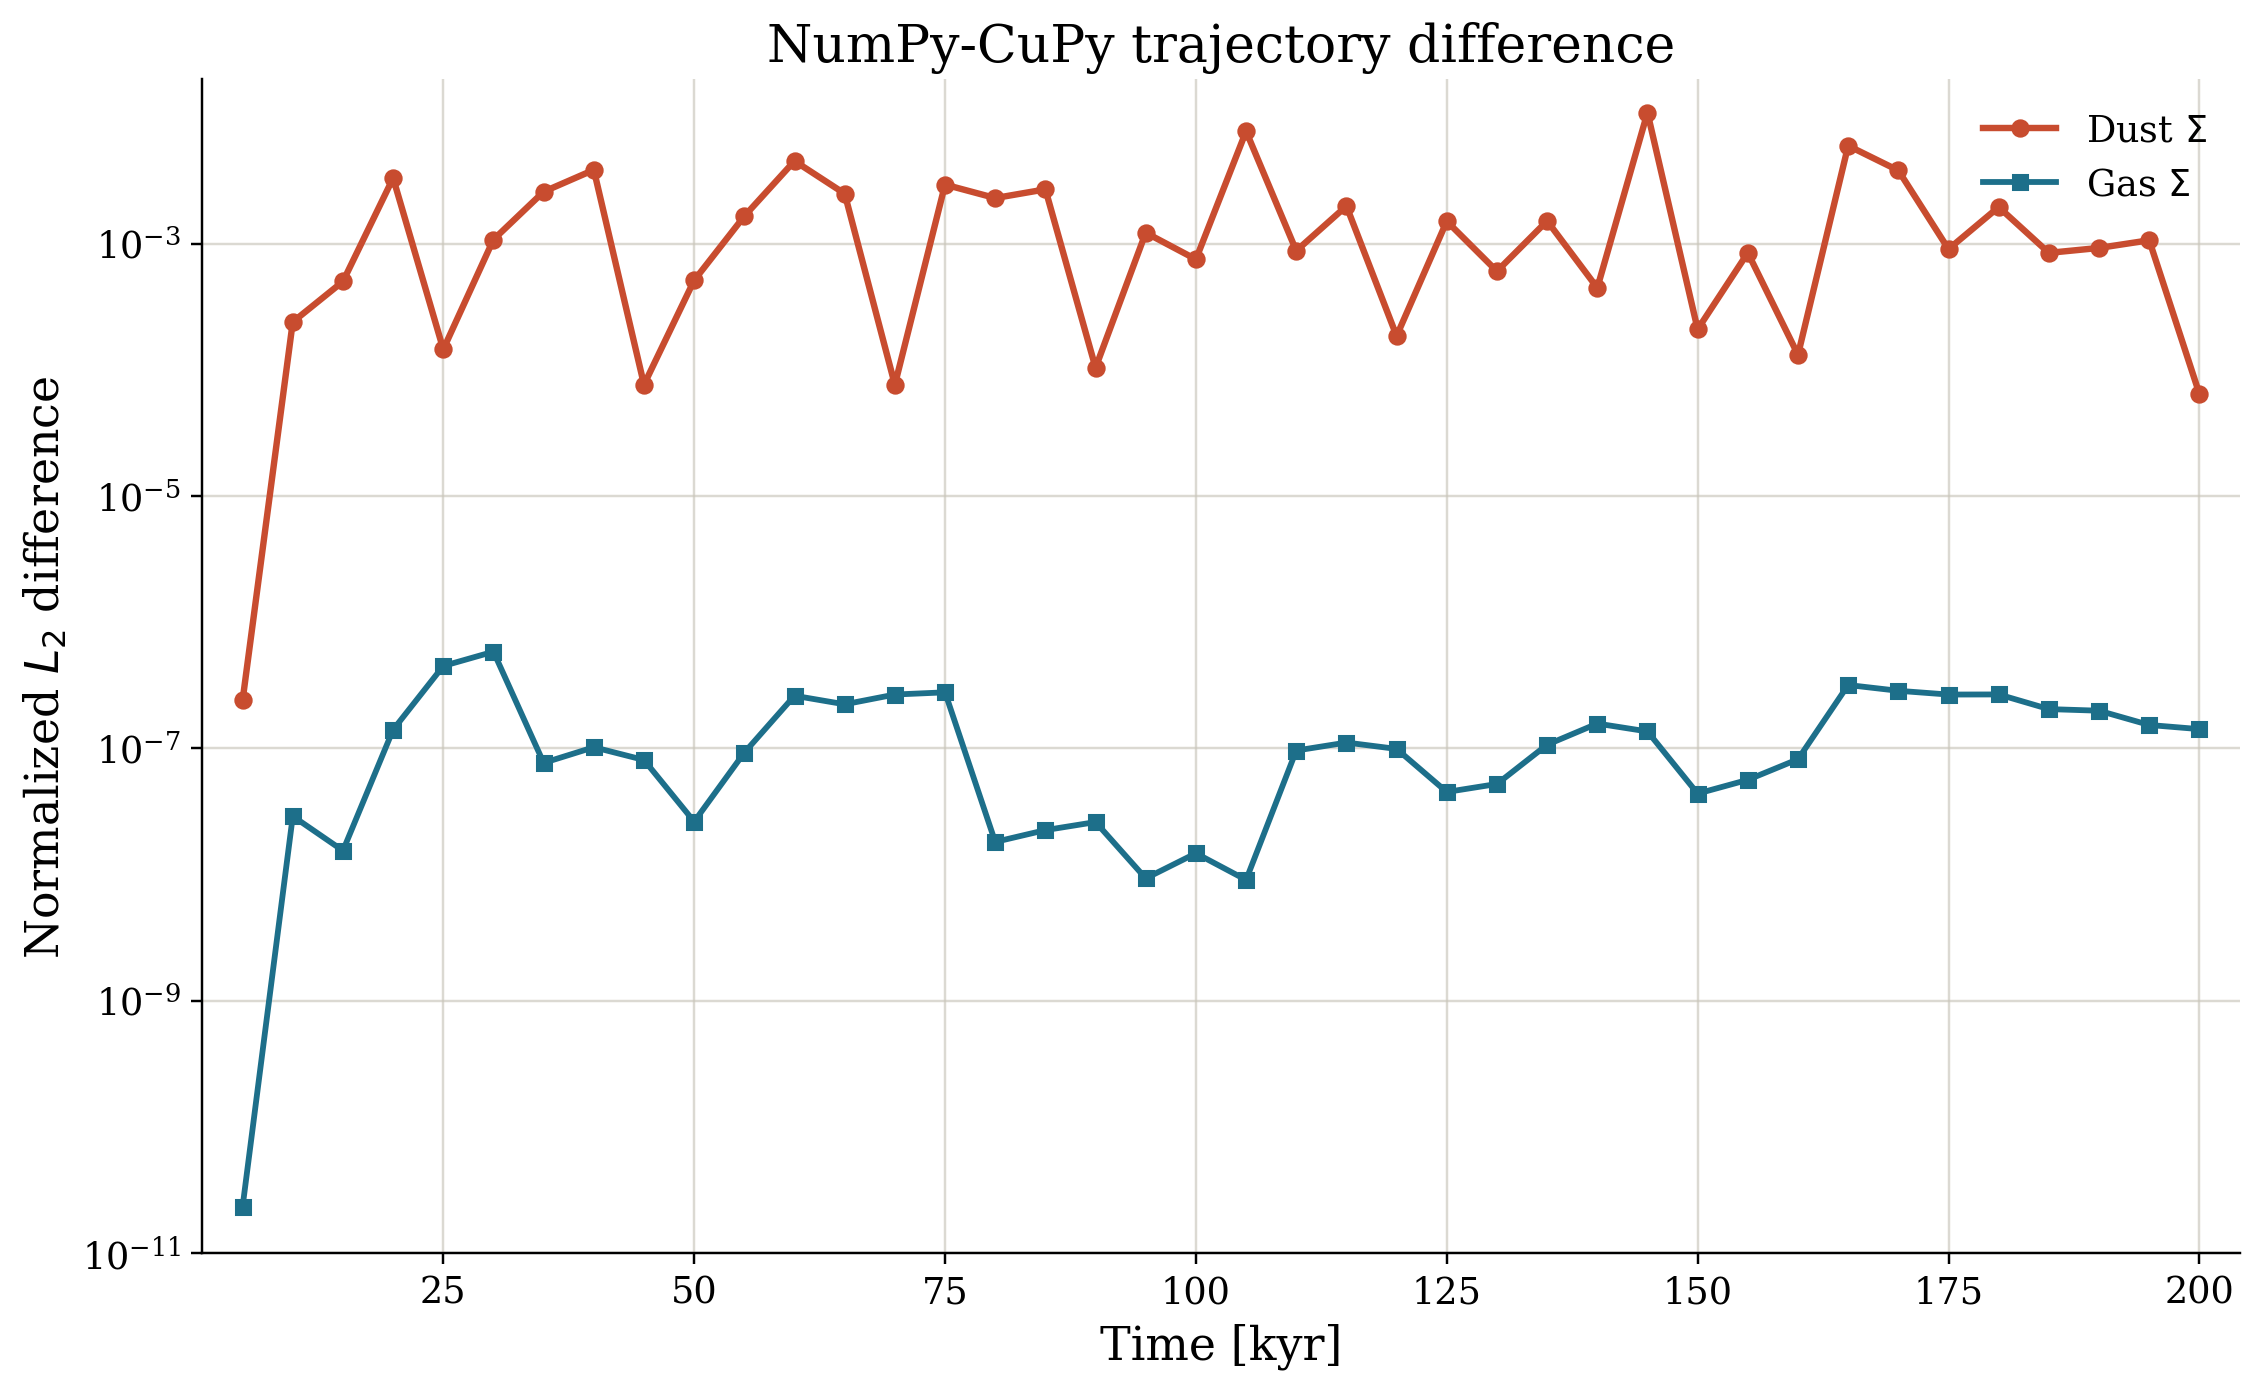

#### Interpretation

The normalized \(L_2\) difference oscillates non-monotonically and does **not** accumulate continuously with time. Dust remains near the \(10^{-3}\) scale, while Gas remains at the \(10^{-6}\) scale or below. Temporary excursions are followed by convergence toward smaller differences.

### 2.3. Official example comparison

The following figures compare the published DustPy examples with their DustPy-GPU CuPy counterparts.

#### Ice Lines

**Surface-density evolution**

| DustPy | DustPy-GPU (`backend="cupy"`) |
| :---: | :---: |
| 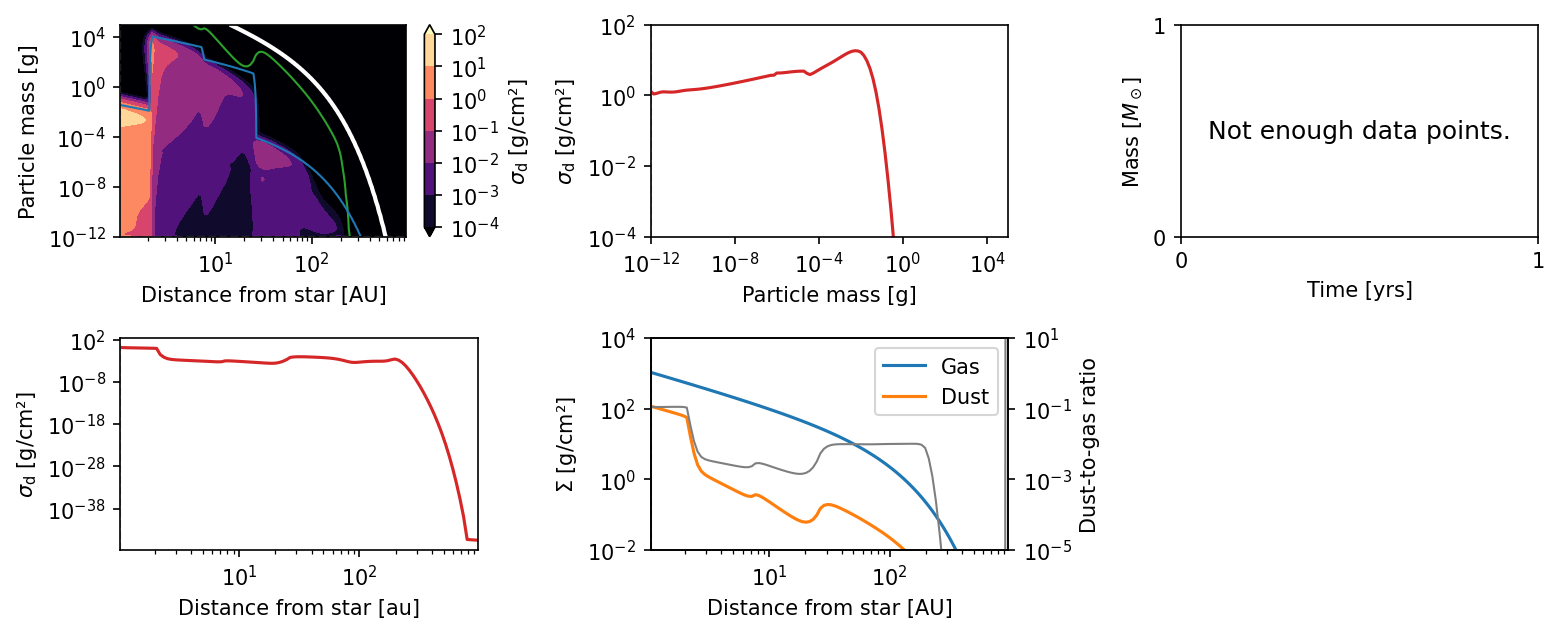 | 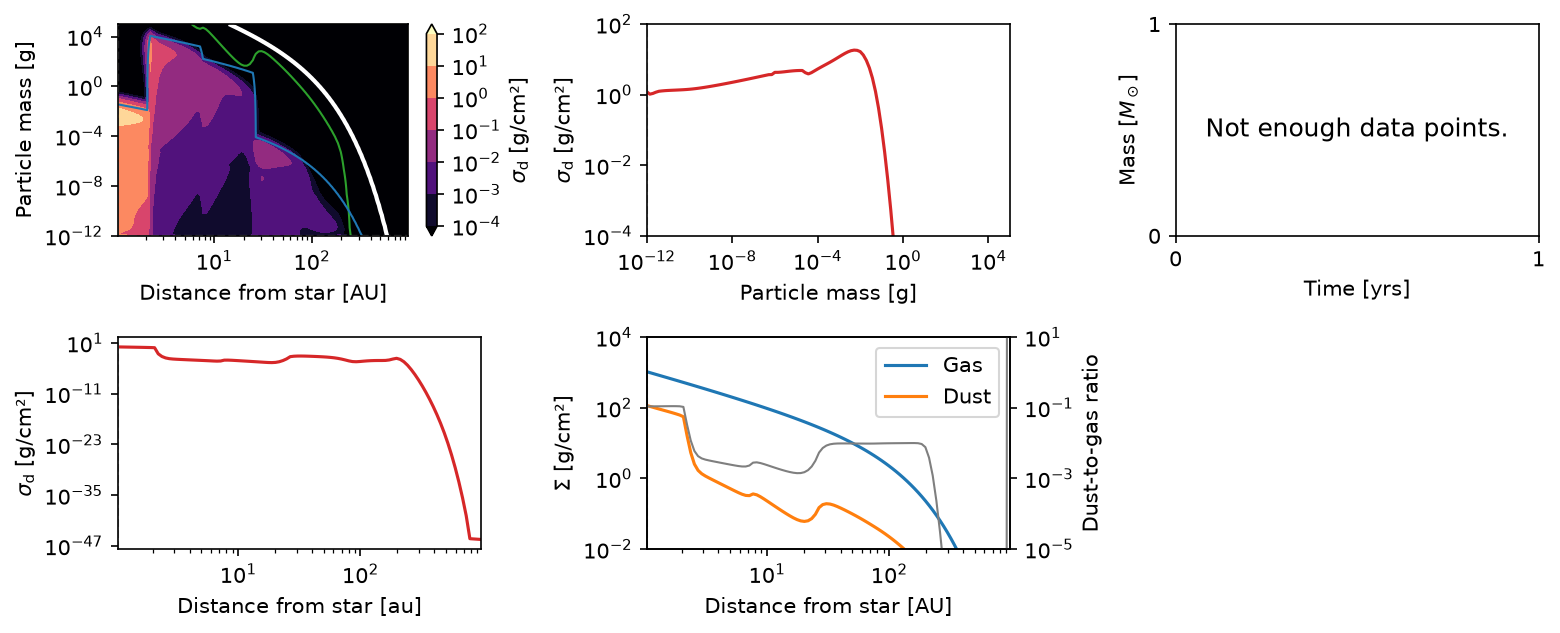 |

#### Planetary Gaps

**Surface-density evolution**

| DustPy | DustPy-GPU (`backend="cupy"`) |
| :---: | :---: |
| 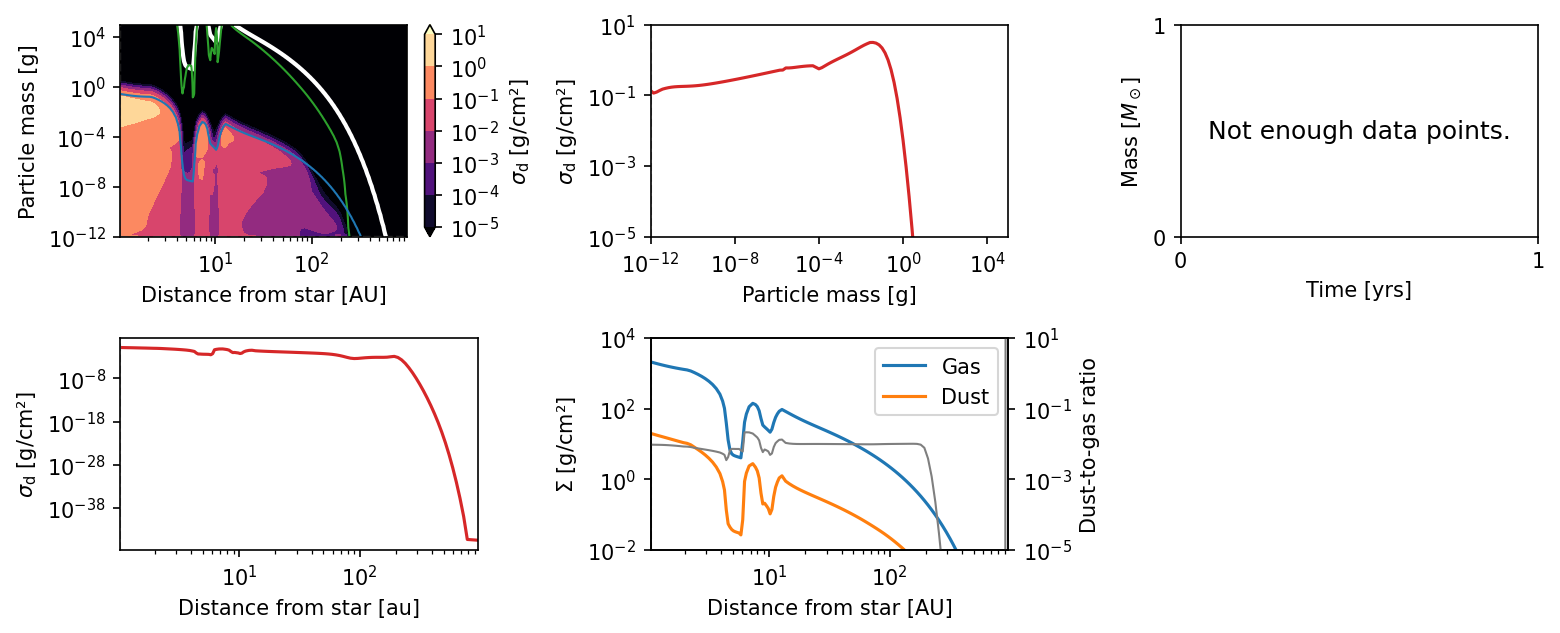 | 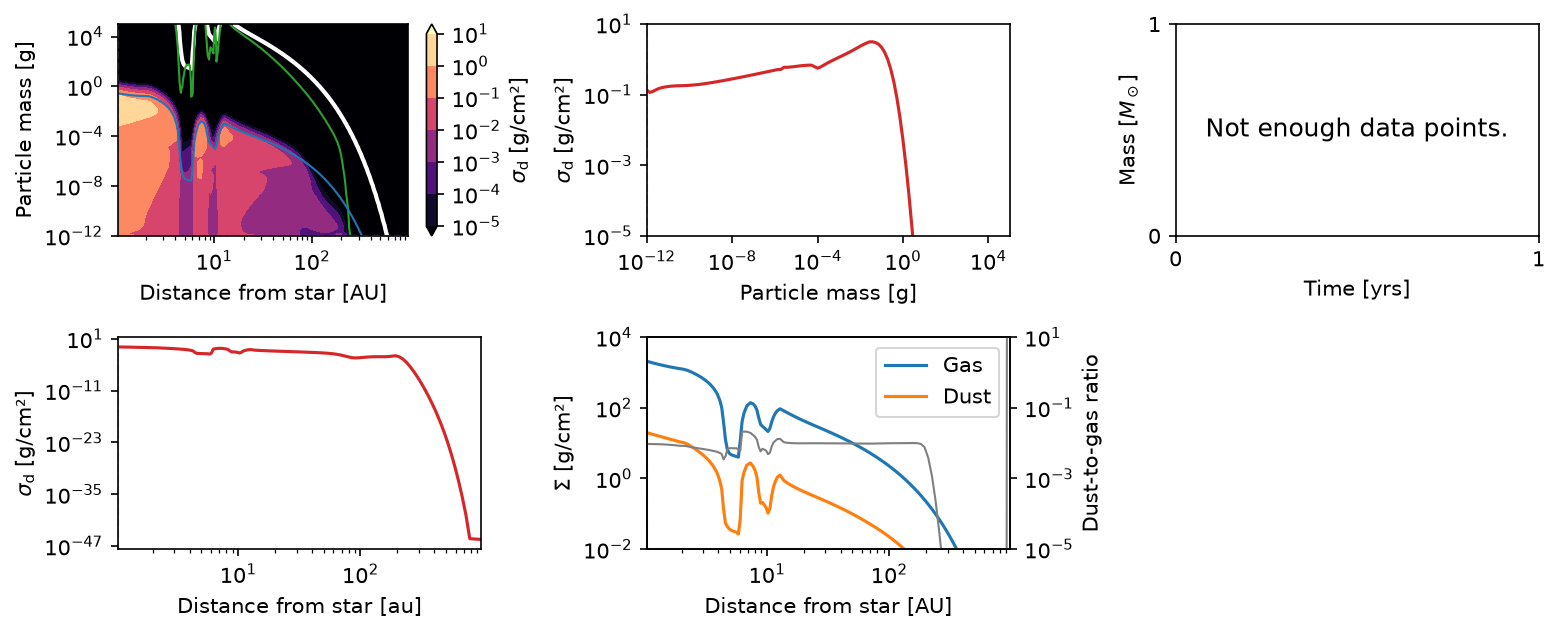 |

#### Planetesimal Formation

**Surface-density evolution**

| DustPy | DustPy-GPU (`backend="cupy"`) |
| :---: | :---: |
| 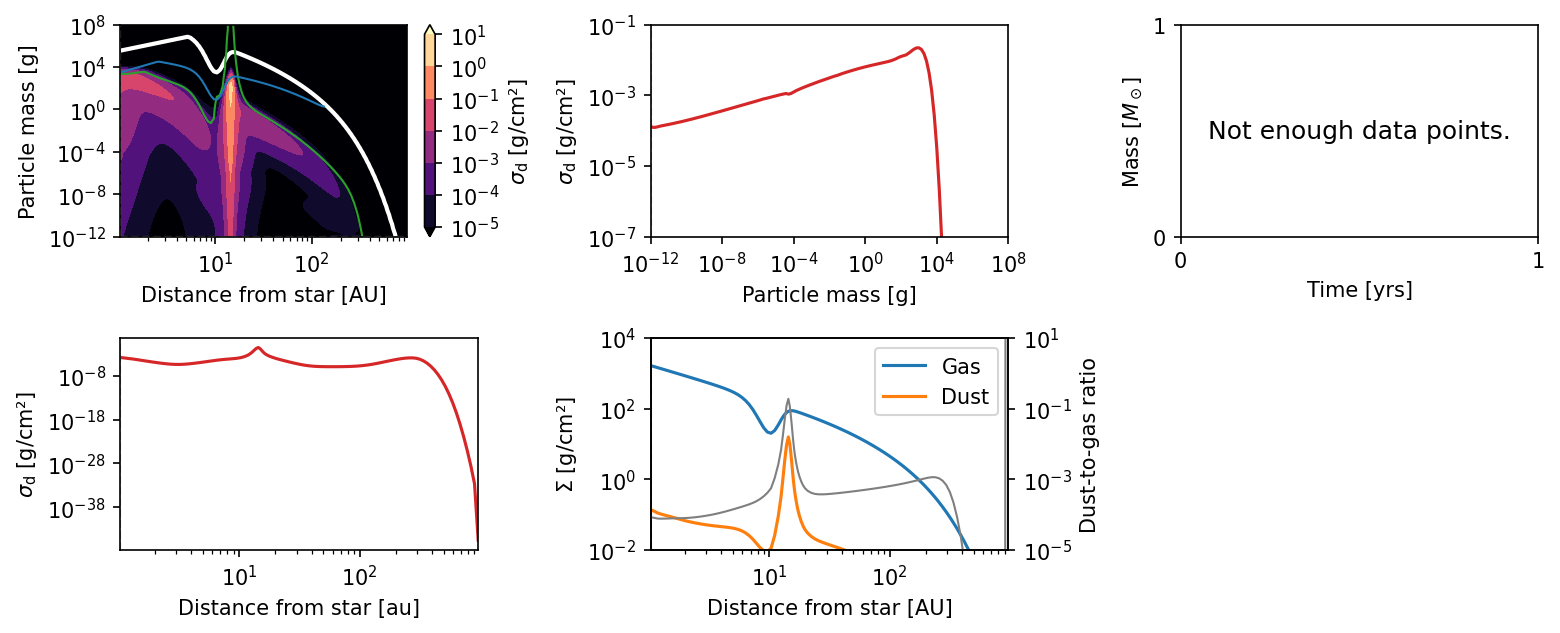 | 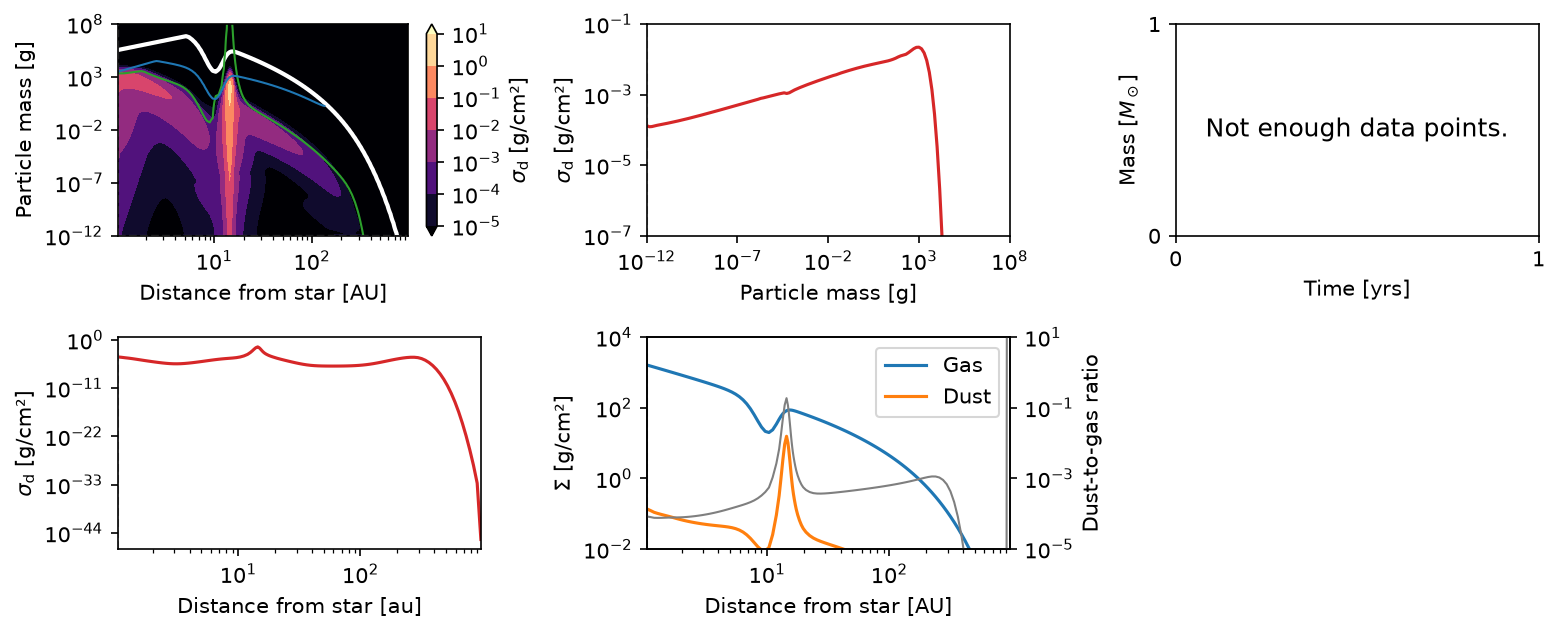 |

**Mass history**

| DustPy | DustPy-GPU (`backend="cupy"`) |
| :---: | :---: |
| 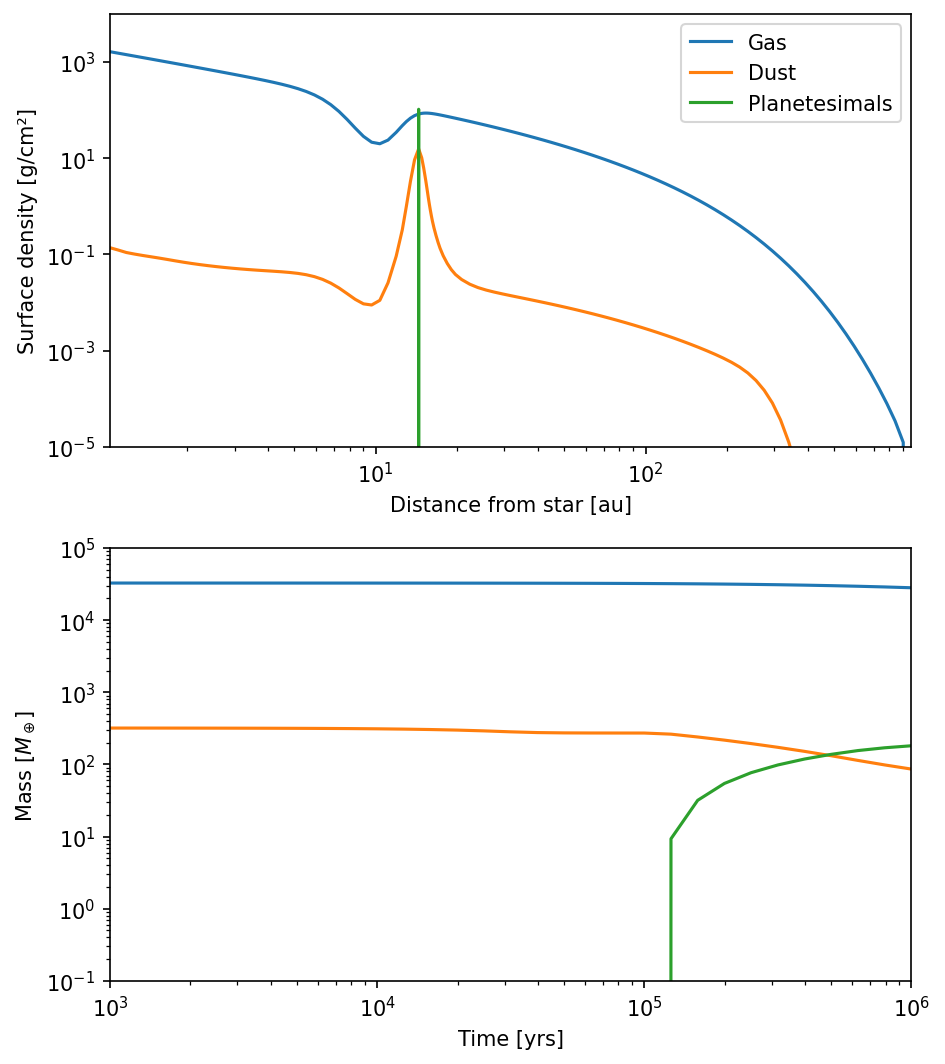 | 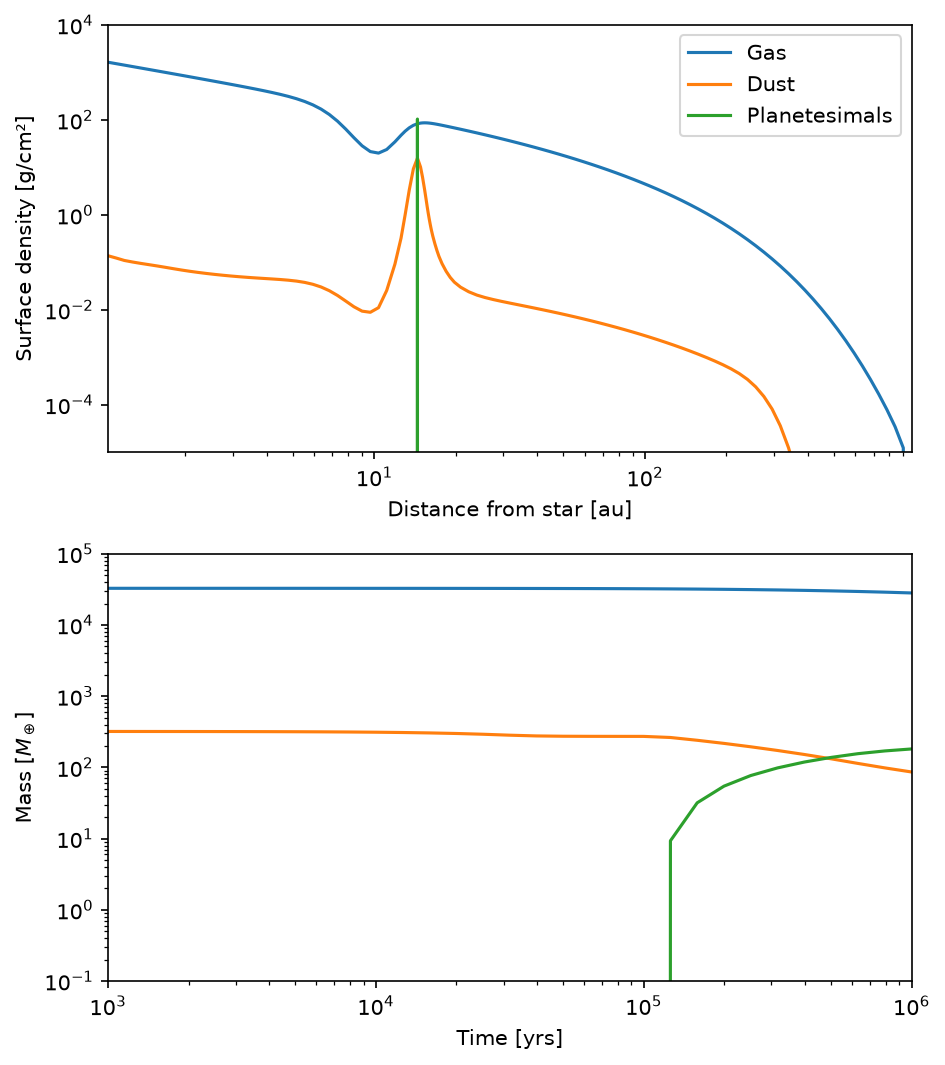 |

The paired figures are visually indistinguishable at the plotting resolution. This confirms that the small backend-level numerical differences do not alter the physical conclusions of these examples.

## 3. Performance benchmarks

Cycle throughput is measured over the continued-run window from 1 kyr to 5 kyr:

$$
\mathrm{cycles\ per\ second} =
\frac{N_{\rm cycle}(5\,\mathrm{kyr})-N_{\rm cycle}(1\,\mathrm{kyr})}
{t_{\rm wall}(5\,\mathrm{kyr})-t_{\rm wall}(1\,\mathrm{kyr})}.
$$

Initialization and the first 1 kyr are excluded. NumPy uses one CPU thread; `Nm=120` and all model parameters remain at their defaults, with only `Nr` varied.

### Hardware

| System | CPU | GPU |
| :--- | :--- | :--- |
| Machine A | Intel Core i9-13900HX | NVIDIA GeForce RTX 4080 Laptop GPU (12 GB) |
| Machine B | Intel Xeon Gold 6448Y | NVIDIA H100 80GB HBM3 |

### Throughput

| System | `Nr` | NumPy [cycles/s] | CuPy [cycles/s] | Speedup |
| :--- | ---: | ---: | ---: | ---: |
| Machine A | `100` | `7.705` | `18.460` | **2.40x** |
| Machine A | `200` | `3.101` | `17.314` | **5.58x** |
| Machine A | `300` | `1.530` | `14.528` | **9.50x** |
| Machine B | `100` | `4.894` | `29.592` | **6.05x** |
| Machine B | `200` | `2.428` | `33.545` | **13.82x** |
| Machine B | `300` | `1.397` | `35.682` | **25.54x** |

GPU acceleration becomes more pronounced as the radial grid is refined. On the H100, the CuPy throughput increases with `Nr`, indicating better utilization for the larger workloads.